# EDA & Preprocessing


## 1.1 Install dependencies

In [1]:
#pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap lightgbm imbalanced-learn joblib

## 1.2 Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings, os, joblib
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
os.makedirs("../results/eda",        exist_ok=True)
os.makedirs("../results/models",     exist_ok=True)
os.makedirs("../data/processed",     exist_ok=True)
os.makedirs("../models",             exist_ok=True)
print("Ready.")


Ready.


## 1.3 Load dataset

In [3]:
# ── Point this to your CSV ───────────────────────────────────
DATA_PATH   = "../data/raw/European_Bank.csv"        # <-- update path
RANDOM_SEED = 42

df_raw = pd.read_csv(DATA_PATH)
print("Shape:", df_raw.shape)
print("Columns:", df_raw.columns.tolist())
df_raw.head()


Shape: (10000, 14)
Columns: ['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 1.4 Initial inspection

In [4]:
print("=== Data Types ===")
print(df_raw.dtypes)
print()
print("=== Missing values ===")
print(df_raw.isnull().sum())
print()
print("=== Target distribution ===")
vc = df_raw["Exited"].value_counts()
print(vc)
print(f"Churn rate: {vc[1]/len(df_raw)*100:.1f}%")


=== Data Types ===
Year                 int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

=== Missing values ===
Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

=== Target distribution ===
Exited
0    7963
1    2037
Name: count, dtype: int64
Churn rate: 20.4%


## 1.5 Drop non-informative columns

In [5]:
# CustomerId and Surname carry no predictive signal
DROP_COLS = ["CustomerId", "Surname"]
if "Year" in df_raw.columns:
    DROP_COLS.append("Year")

df = df_raw.drop(columns=[c for c in DROP_COLS if c in df_raw.columns]).copy()
print("Remaining columns:", df.columns.tolist())
print("Shape:", df.shape)


Remaining columns: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
Shape: (10000, 11)


## 1.6 EDA — Univariate

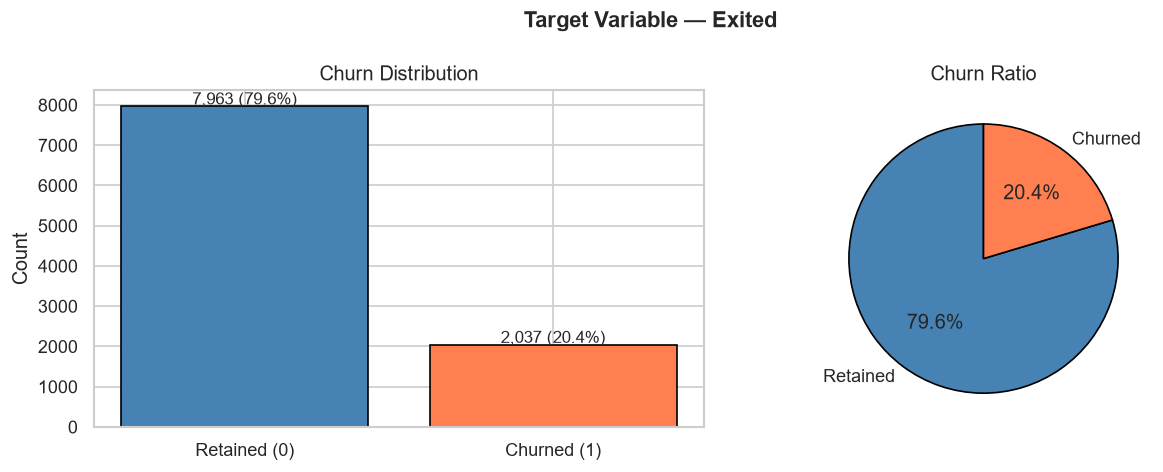

In [6]:
# ── 1.6.1 Churn distribution ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = df["Exited"].value_counts()
axes[0].bar(["Retained (0)", "Churned (1)"], counts.values,
            color=["steelblue", "coral"], edgecolor="black")
axes[0].set_title("Churn Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f"{v:,} ({v/len(df)*100:.1f}%)", ha="center", fontsize=10)

axes[1].pie(counts.values, labels=["Retained", "Churned"],
            colors=["steelblue", "coral"], autopct="%1.1f%%",
            startangle=90, wedgeprops={"edgecolor": "black"})
axes[1].set_title("Churn Ratio")

plt.suptitle("Target Variable — Exited", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/eda/01_churn_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


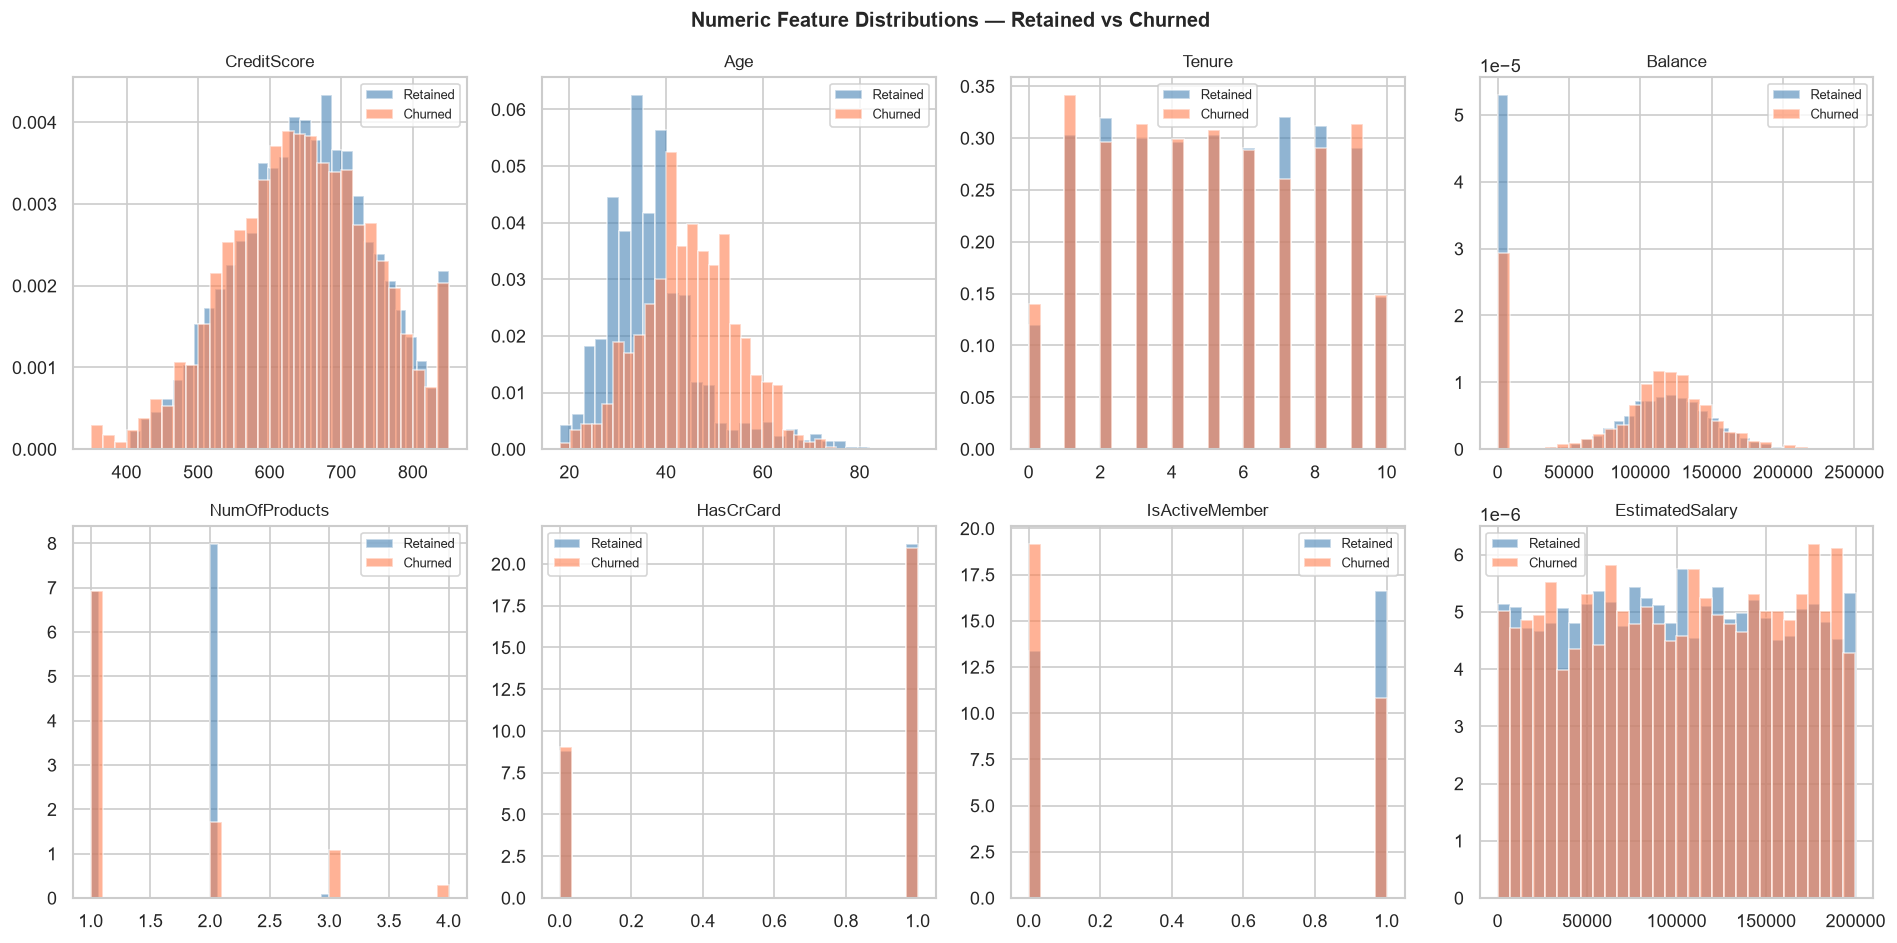

In [7]:
# ── 1.6.2 Numeric feature distributions ──────────────────────
num_cols = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts",
            "HasCrCard", "IsActiveMember", "EstimatedSalary"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[df["Exited"]==0][col], bins=30, alpha=0.6,
                 color="steelblue", label="Retained", density=True)
    axes[i].hist(df[df["Exited"]==1][col], bins=30, alpha=0.6,
                 color="coral", label="Churned", density=True)
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=8)

plt.suptitle("Numeric Feature Distributions — Retained vs Churned",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/eda/02_numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


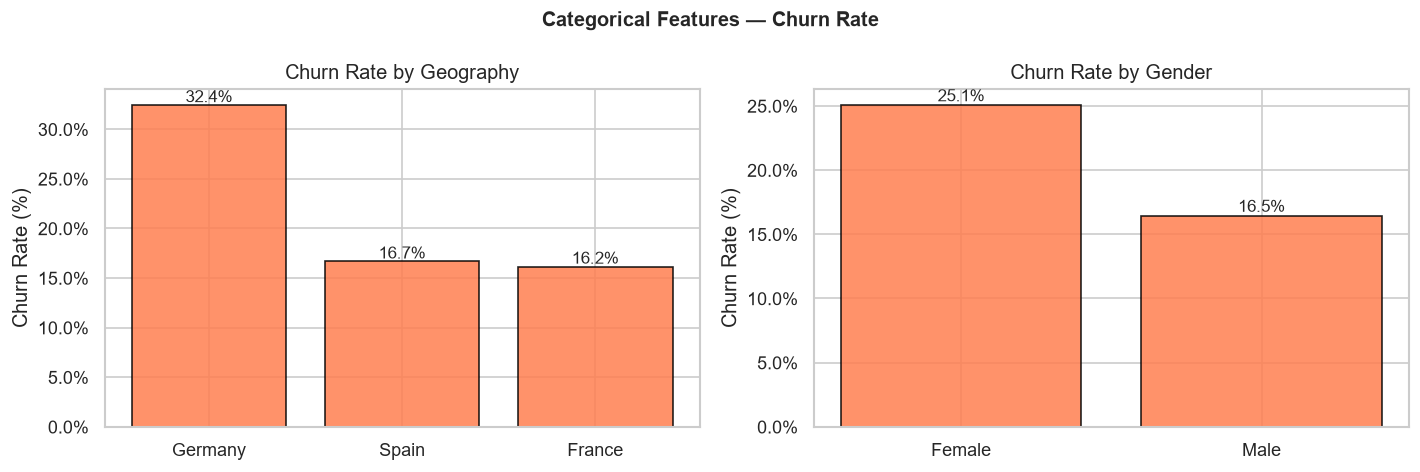

In [8]:
# ── 1.6.3 Categorical features vs churn ──────────────────────
cat_cols = ["Geography", "Gender"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, cat_cols):
    ct = df.groupby(col)["Exited"].mean().sort_values(ascending=False) * 100
    bars = ax.bar(ct.index, ct.values, color="coral", edgecolor="black", alpha=0.85)
    ax.set_title(f"Churn Rate by {col}")
    ax.set_ylabel("Churn Rate (%)")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    for bar, val in zip(bars, ct.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{val:.1f}%", ha="center", fontsize=10)

plt.suptitle("Categorical Features — Churn Rate", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/eda/03_categorical_churn_rates.png", dpi=150, bbox_inches="tight")
plt.show()


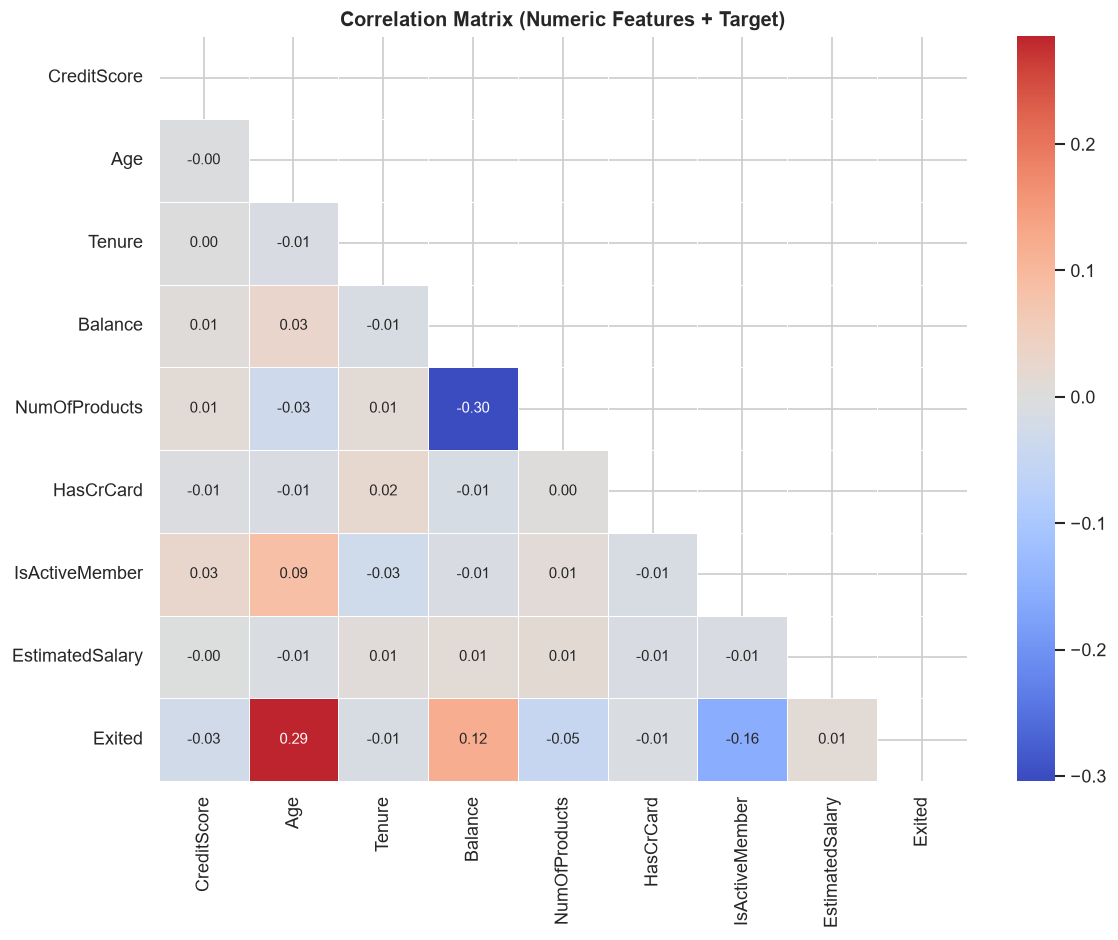

In [9]:
# ── 1.6.4 Correlation heatmap ─────────────────────────────────
plt.figure(figsize=(10, 8))
corr = df[num_cols + ["Exited"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, annot_kws={"size": 9})
plt.title("Correlation Matrix (Numeric Features + Target)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/eda/04_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


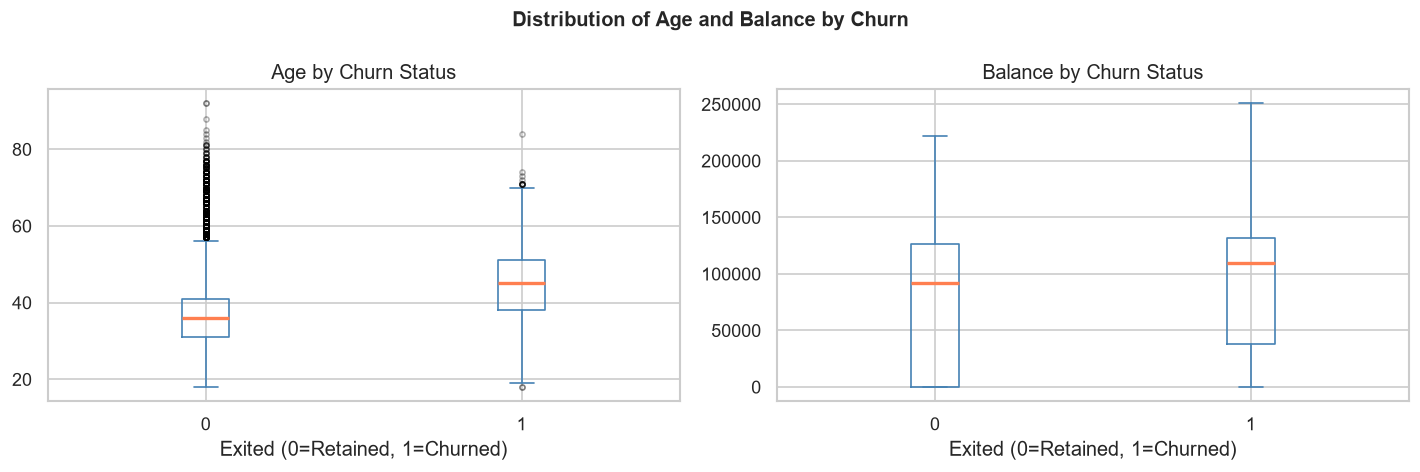

In [10]:
# ── 1.6.5 Box plots — Age and Balance by churn ────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, ["Age", "Balance"]):
    df.boxplot(column=col, by="Exited", ax=ax,
               boxprops=dict(color="steelblue"),
               medianprops=dict(color="coral", linewidth=2),
               whiskerprops=dict(color="steelblue"),
               capprops=dict(color="steelblue"),
               flierprops=dict(marker="o", color="gray", alpha=0.3, markersize=3))
    ax.set_title(f"{col} by Churn Status")
    ax.set_xlabel("Exited (0=Retained, 1=Churned)")
    plt.suptitle("")

plt.suptitle("Distribution of Age and Balance by Churn", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/eda/05_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()


## 1.7 Feature Engineering

In [11]:
def engineer_features(df):
    df = df.copy()

    # Balance-to-Salary ratio: high ratio may indicate high financial exposure
    df["BalanceToSalary"]      = df["Balance"] / (df["EstimatedSalary"] + 1)

    # Product density: normalised product count per year of tenure
    df["ProductDensity"]       = df["NumOfProducts"] / (df["Tenure"] + 1)

    # Engagement-product interaction: active member with multiple products
    df["EngagementProduct"]    = df["IsActiveMember"] * df["NumOfProducts"]

    # Age-Tenure interaction: older customers with less tenure = late adopters
    df["AgeTenureInteraction"] = df["Age"] * df["Tenure"]

    # Zero balance flag: customers with 0 balance may be disengaged
    df["IsZeroBalance"]        = (df["Balance"] == 0).astype(int)

    # Credit score bucket
    df["CreditScoreBucket"]    = pd.cut(df["CreditScore"],
                                         bins=[0, 579, 669, 739, 799, 900],
                                         labels=["Poor","Fair","Good","VGood","Excellent"])
    df["CreditScoreBucket"]    = df["CreditScoreBucket"].astype(str)

    return df

df = engineer_features(df)
print("New features added. Shape:", df.shape)
print("New columns:", ["BalanceToSalary","ProductDensity","EngagementProduct",
                       "AgeTenureInteraction","IsZeroBalance","CreditScoreBucket"])


New features added. Shape: (10000, 17)
New columns: ['BalanceToSalary', 'ProductDensity', 'EngagementProduct', 'AgeTenureInteraction', 'IsZeroBalance', 'CreditScoreBucket']


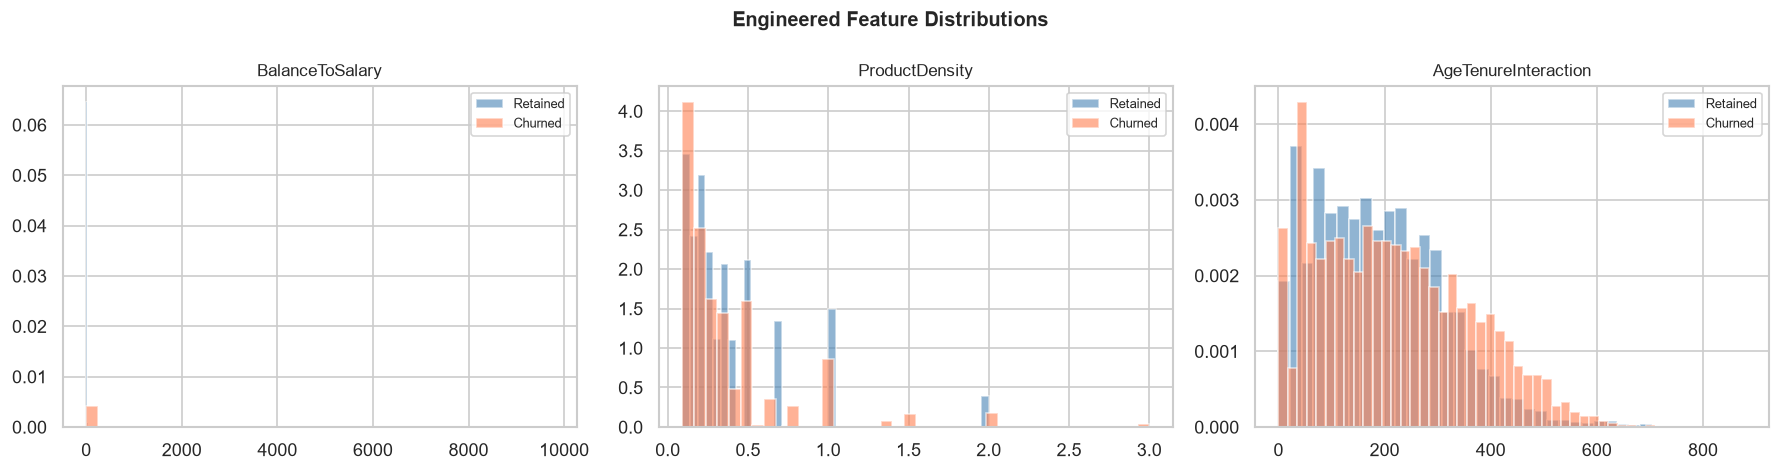

In [12]:
# Visualise key engineered features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ["BalanceToSalary", "ProductDensity", "AgeTenureInteraction"]):
    ax.hist(df[df["Exited"]==0][col], bins=40, alpha=0.6,
            color="steelblue", label="Retained", density=True)
    ax.hist(df[df["Exited"]==1][col], bins=40, alpha=0.6,
            color="coral", label="Churned", density=True)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle("Engineered Feature Distributions", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/eda/06_engineered_features.png", dpi=150, bbox_inches="tight")
plt.show()


## 1.8 Encoding & Scaling

In [13]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# One-hot encode Geography and Gender
df_enc = pd.get_dummies(df, columns=["Geography", "Gender", "CreditScoreBucket"],
                         drop_first=False)

# Drop original categoricals (already encoded)
feature_cols = [c for c in df_enc.columns if c != "Exited"]
X = df_enc[feature_cols].copy()
y = df_enc["Exited"].copy()

print("Feature matrix shape:", X.shape)
print("Features:", X.columns.tolist())
print("Class distribution:", y.value_counts().to_dict())


Feature matrix shape: (10000, 23)
Features: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'BalanceToSalary', 'ProductDensity', 'EngagementProduct', 'AgeTenureInteraction', 'IsZeroBalance', 'Geography_France', 'Geography_Germany', 'Geography_Spain', 'Gender_Female', 'Gender_Male', 'CreditScoreBucket_Excellent', 'CreditScoreBucket_Fair', 'CreditScoreBucket_Good', 'CreditScoreBucket_Poor', 'CreditScoreBucket_VGood']
Class distribution: {0: 7963, 1: 2037}


In [14]:
# ── Train / test split (stratified) ──────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y
)

print(f"Train: {X_train.shape} | Churn: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Test : {X_test.shape}  | Churn: {y_test.sum()} ({y_test.mean()*100:.1f}%)")

# ── Scale for LR / SVM models ────────────────────────────────
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns)

churn_rate   = y_train.mean()
scale_pos_wt = (1 - churn_rate) / churn_rate
print(f"\nscale_pos_weight for XGBoost: {scale_pos_wt:.3f}")


Train: (8000, 23) | Churn: 1630 (20.4%)
Test : (2000, 23)  | Churn: 407 (20.3%)

scale_pos_weight for XGBoost: 3.908


## 1.9 Save preprocessed data

In [15]:
joblib.dump({
    "X_train": X_train, "X_test": X_test,
    "X_train_sc": X_train_sc, "X_test_sc": X_test_sc,
    "y_train": y_train, "y_test": y_test,
    "feature_cols": list(X.columns),
    "scaler": scaler,
    "scale_pos_weight": scale_pos_wt
}, "../data/processed/churn_preprocessed.pkl")

print("Saved: data/processed/churn_preprocessed.pkl")



Saved: data/processed/churn_preprocessed.pkl
